In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split as tts, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("uci breast cancer dataset.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
df.shape # "This line prints the number of rows and columns in the DataFrame. The output is shown as a tuple in the format (rows, columns)."

(569, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

## Data Preprocessing

In [7]:
df = df.drop(["id","Unnamed: 32"],axis = 'columns')
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [8]:
df.diagnosis.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

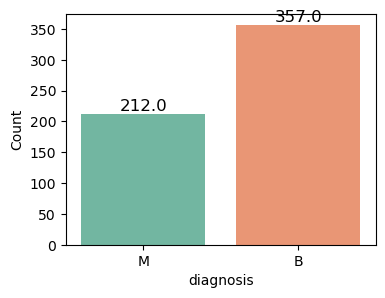

In [9]:
# Create the countplot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(4, 3))
ax = sns.countplot(x='diagnosis', data=df, palette='Set2')

# Annotate the bars with their respective counts
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=12)

# Optionally, you can set the y-axis label
plt.ylabel('Count')

# Show the plot
plt.show()


## Splitting the dataset

In [11]:
x = df.drop("diagnosis",axis = 1)
y = df[["diagnosis"]]

In [12]:
xtrain, xtest, ytrain, ytest = tts(x,y, test_size = .2, random_state = 1)

In [13]:
# Create object of RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(xtrain, ytrain)

RandomForestClassifier()

In [14]:
print("Training Accuracy:", rf.score(xtrain, ytrain))
print("Testing Accuracy:", rf.score(xtest, ytest))

Training Accuracy: 1.0
Testing Accuracy: 0.956140350877193


In [15]:
# Predict target values for test set
y_pred = rf.predict(xtest)

# Compare with actual values
print("Predicted values:", y_pred)
print("Actual values:", ytest)

Predicted values: ['B' 'M' 'B' 'M' 'B' 'M' 'M' 'M' 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'B' 'B' 'B'
 'B' 'M' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'M' 'M' 'M' 'M' 'B' 'M' 'M' 'B' 'B'
 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'M' 'M' 'B' 'B'
 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'B'
 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'M' 'B' 'B' 'M' 'B' 'M' 'B'
 'B' 'M' 'B' 'B' 'M' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B'
 'M' 'M' 'M' 'B' 'B' 'B']
Actual values:     diagnosis
421         B
47          M
292         B
186         M
414         M
..        ...
172         M
3           M
68          B
448         B
442         B

[114 rows x 1 columns]


In [16]:
accuracy = accuracy_score(ytest, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.956140350877193


## The model correctly predicted 95.61% of the test samples. It’s a good overall score, especially if the dataset isn’t heavily imbalanced.

In [18]:
cm = confusion_matrix(ytest, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[72  0]
 [ 5 37]]


## 72 Benign (B) cases correctly classified.

## 37 Malignant (M) cases correctly classified.

## 5 Malignant (M) cases incorrectly classified as Benign.

## 0 Benign misclassified as Malignant.

In [20]:
report = classification_report(ytest, y_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           B       0.94      1.00      0.97        72
           M       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



##  Class B (Benign):
## Precision 0.94: Out of all predicted B, 94% were actually B.

## Recall 1.00: Out of all actual B, 100% were correctly predicted.

## F1-Score 0.97: Balance of precision & recall — very strong performance.

##  Class M (Malignant):
## Precision 1.00: Out of all predicted M, 100% were actually M (no false positives).

## Recall 0.88: Out of all actual M, 88% were correctly predicted — 5 M cases were missed.

## F1-Score 0.94: Slightly lower than B because recall dropped a bit.

In [22]:
accuracy = accuracy_score(ytest, y_pred)
print("Accuracy:", accuracy)
cm = confusion_matrix(ytest, y_pred)
print("\nConfusion Matrix:\n", cm)
report = classification_report(ytest, y_pred)
print("\nClassification Report:\n", report)


Accuracy: 0.956140350877193

Confusion Matrix:
 [[72  0]
 [ 5 37]]

Classification Report:
               precision    recall  f1-score   support

           B       0.94      1.00      0.97        72
           M       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



## Random Forest with OOB (Out-of-Bag) Score

In [24]:
rof = RandomForestClassifier(oob_score=True)
rof.fit(xtrain,ytrain)

RandomForestClassifier(oob_score=True)

In [25]:
print("Training accuracy: ",rof.score(xtrain,ytrain))
print("Testing accuracy: ",rof.score(xtest,ytest))

Training accuracy:  1.0
Testing accuracy:  0.9473684210526315


In [26]:
accuracy_rof = accuracy_score(ytest, y_pred)
print("Accuracy:", accuracy)
cm_rof = confusion_matrix(ytest, y_pred)
print("Confusion Matrix:\n", cm)
report_rof = classification_report(ytest, y_pred)
print("Classification Report:\n", report)


Accuracy: 0.956140350877193
Confusion Matrix:
 [[72  0]
 [ 5 37]]
Classification Report:
               precision    recall  f1-score   support

           B       0.94      1.00      0.97        72
           M       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



## Pre Pruning Cost Complexity
## Random Forest with Grid Search

In [28]:
param_grid = {
    "n_estimators": [100, 200],
    "criterion": ["gini","entropy"],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2,5,10],
    'min_samples_leaf': [1,2,4],
    "max_features": ["auto","sqrt", "log2"]
}

In [29]:
rf_grid_src = GridSearchCV(estimator=RandomForestClassifier(random_state=42, oob_score = True),param_grid = param_grid, cv=5)

In [30]:
rf_grid_src

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(oob_score=True, random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]})

In [31]:
rf_grid_src.fit(xtrain,ytrain)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(oob_score=True, random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]})

In [32]:
print(rf_grid_src.best_params_)

{'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [56]:
print(rf_grid_src.best_estimator_.oob_score_)

0.9560439560439561


## Evaluate optimized model for Random Forest

In [41]:
y_pred_rn = rf_grid_src.predict(xtest)
y_pred_rn

array(['B', 'M', 'B', 'M', 'B', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'M',
       'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B',
       'B', 'M', 'M', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'M',
       'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B',
       'B', 'M', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B', 'B',
       'M', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'M', 'M', 'M', 'B', 'B', 'B'], dtype=object)

In [43]:
print("---Accuracy score of Random Forest with Grid Search---")
print("Accuracy score: ",accuracy_score(y_pred_rn, ytest))

---Accuracy score of Random Forest with Grid Search---
Accuracy score:  0.956140350877193


In [58]:
print("---Calssification report of Random Forest with Grid Search---")
print("Classification Report:\n ",classification_report(y_pred_rn, ytest))

---Calssification report of Random Forest with Grid Search---
Classification Report:
                precision    recall  f1-score   support

           B       1.00      0.94      0.97        77
           M       0.88      1.00      0.94        37

    accuracy                           0.96       114
   macro avg       0.94      0.97      0.95       114
weighted avg       0.96      0.96      0.96       114



## Random Forest with Randomized Search

In [66]:
rf_ran_src = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), param_distributions = param_grid, cv = 5, n_iter = 100)
rf_ran_src

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 10, 20, 30],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200]})

In [ ]:
rf_ran_src.fit(xtrain,ytrain)

In [ ]:
print(rf_ran_src.best_params_)

In [ ]:
new_ypred = rf_ran_src(xtest)
new_ypred

In [ ]:
print("---Accuracy score of Random Forest with Randomized Search---")
print("Accuracy score: ",accuracy_score(new_ypred, ytest))


In [ ]:
print("---\nCalssification report of Random Forest with Randomized Search---")
print("Classification Report: ",classification_report(new_ypred, ytest))